# Live Webcam Depth with Depth Anything V2

This notebook reads frames from your webcam and runs **Depth Anything V2** on each one. It shows the camera and the depth map together in a live window, either side by side or blended.

## How to run

**One-time setup** (already done on this machine. Repeat it only on a fresh clone):

```bash
cd eye-in-the-sky
python -m venv .venv
.venv/bin/pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
.venv/bin/pip install opencv-python matplotlib ipykernel
.venv/bin/python -m ipykernel install --user --name eye-in-the-sky --display-name "Python (eye-in-the-sky)"
git clone https://github.com/DepthAnything/Depth-Anything-V2
mkdir -p Depth-Anything-V2/checkpoints
curl -L -o Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth \
  "https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth?download=true"
```

(Arch blocks system-wide `pip install`, which is why everything goes in `.venv`. The repo's `gradio` requirement is only for its web demo and is not needed here.)

**Every time:**

1. In VS Code, click **Select Kernel** (top right) → *Jupyter Kernel* → **Python (eye-in-the-sky)**.
2. Run cells 1–4 in order. Cell 4 shows one webcam frame and its depth map inline as a sanity check.
3. Run cell 5. A separate window called **Depth Anything V2** opens. Click it to give it focus, then use the keys:
   - `q` or `Esc`: quit (the camera is released)
   - `m`: switch between side-by-side and blended views
   - `+` / `-`: change blend strength
   - `s`: save a snapshot PNG to `snapshots/`
4. While cell 5 runs it blocks the kernel. Quit with `q` before running other cells.

**Performance:** on CPU, speed depends mostly on `INPUT_SIZE`. Raw inference with the Small model on this laptop: 252 → ~7 FPS, 364 → ~2 FPS, 518 → ~1 FPS. The live window at 252 runs at ~4–5 FPS.

In [1]:
# Cell 1: config + imports
import os, sys, time
os.environ.setdefault('QT_QPA_PLATFORM', 'xcb')  # OpenCV's Qt has no Wayland plugin; use XWayland

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_DIR = 'Depth-Anything-V2'  # cloned repo, relative to this notebook
ENCODER = 'vits'                # 'vits' (Small), 'vitb' (Base), 'vitl' (Large); needs the matching checkpoint
INPUT_SIZE = 252                # model input resolution (multiple of 14). Lower = faster, higher = more detail
CAMERA_INDEX = 0                # /dev/video0
FRAME_W, FRAME_H = 640, 480
COLORMAP = cv2.COLORMAP_INFERNO

sys.path.insert(0, REPO_DIR)
from depth_anything_v2.dpt import DepthAnythingV2

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch, 'xpu') and torch.xpu.is_available():
    DEVICE = 'xpu'  # Intel Arc (needs the XPU build of torch)
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
    torch.set_num_threads(os.cpu_count())
print(f'torch {torch.__version__} | OpenCV {cv2.__version__} | device: {DEVICE}')

xFormers not available
xFormers not available


torch 2.14.1+cpu | OpenCV 5.0.0 | device: cpu


In [2]:
# Cell 2: load the model
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64,  'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}
ckpt = os.path.join(REPO_DIR, 'checkpoints', f'depth_anything_v2_{ENCODER}.pth')

model = DepthAnythingV2(**model_configs[ENCODER])
model.load_state_dict(torch.load(ckpt, map_location='cpu'))
model = model.to(DEVICE).eval()
print(f'Loaded {ckpt}')

Loaded Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth


In [3]:
# Cell 3: webcam + helpers
def open_camera():
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_V4L2)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_W)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_H)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)  # keep latency low: always grab the newest frame
    if not cap.isOpened():
        raise RuntimeError(f'Could not open camera {CAMERA_INDEX}. Is another app using it?')
    return cap

@torch.inference_mode()
def estimate_depth(frame_bgr):
    # Relative inverse depth (bigger = closer), same HxW as the input frame
    return model.infer_image(frame_bgr, INPUT_SIZE)

class DepthColorizer:
    # Normalizes depth to 0-255 using a smoothed min/max so the colours don't flicker between frames
    def __init__(self, momentum=0.9):
        self.momentum, self.lo, self.hi = momentum, None, None

    def __call__(self, depth):
        lo, hi = np.percentile(depth, (2, 98))
        if self.lo is None:
            self.lo, self.hi = lo, hi
        else:
            self.lo = self.momentum * self.lo + (1 - self.momentum) * lo
            self.hi = self.momentum * self.hi + (1 - self.momentum) * hi
        norm = np.clip((depth - self.lo) / max(self.hi - self.lo, 1e-6), 0, 1)
        return cv2.applyColorMap((norm * 255).astype(np.uint8), COLORMAP)

def fuse(frame, depth_color, mode, alpha):
    if mode == 'blend':
        return cv2.addWeighted(frame, 1 - alpha, depth_color, alpha, 0)
    return np.hstack([frame, depth_color])

Inference: 461 ms | frame (480, 640, 3) | depth (480, 640)


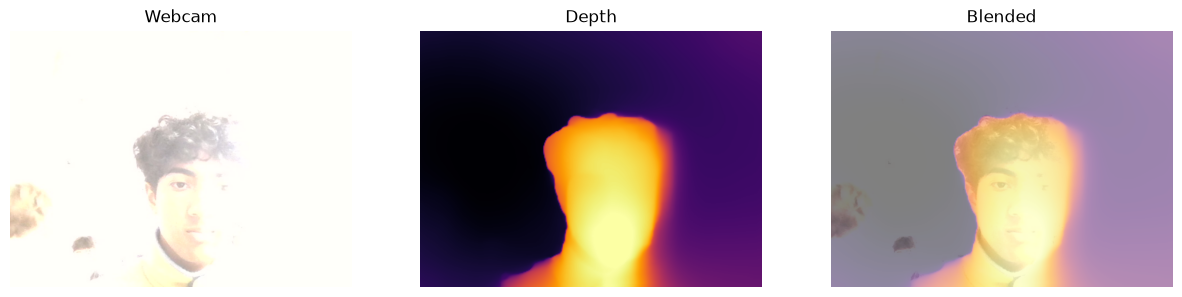

In [4]:
# Cell 4: sanity check, one frame shown inline
cap = open_camera()
for _ in range(5):  # let auto-exposure settle
    ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError('Camera opened but returned no frame')

t = time.time()
depth = estimate_depth(frame)
print(f'Inference: {(time.time() - t) * 1000:.0f} ms | frame {frame.shape} | depth {depth.shape}')

depth_color = DepthColorizer()(depth)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, img, title in zip(ax, [frame, depth_color, fuse(frame, depth_color, 'blend', 0.5)], ['Webcam', 'Depth', 'Blended']):
    a.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); a.set_title(title); a.axis('off')
plt.show()

## Live depth

Running the next cell opens a separate window. Click the window, then press **`q`** to stop. `m` switches view, `+`/`-` change blend strength, `s` saves a snapshot.

In [6]:
# Cell 5: live loop
WINDOW = 'Depth Anything V2'
mode, alpha = 'side', 0.5
colorize = DepthColorizer()
os.makedirs('snapshots', exist_ok=True)

cap = open_camera()
cv2.namedWindow(WINDOW, cv2.WINDOW_NORMAL)
fps, last = 0.0, time.time()
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print('Lost camera frame, stopping'); break

        depth_color = colorize(estimate_depth(frame))
        view = fuse(frame, depth_color, mode, alpha)

        now = time.time()
        fps = 0.9 * fps + 0.1 / max(now - last, 1e-6) if fps else 1 / max(now - last, 1e-6)
        last = now
        label = f'{fps:4.1f} FPS | {ENCODER} @ {INPUT_SIZE} | {DEVICE} | {mode}' + (f' a={alpha:.1f}' if mode == 'blend' else '')
        cv2.putText(view, label, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.imshow(WINDOW, view)

        key = cv2.waitKey(1) & 0xFF
        if key in (ord('q'), 27):
            break
        elif key == ord('m'):
            mode = 'blend' if mode == 'side' else 'side'
        elif key in (ord('+'), ord('=')):
            alpha = min(alpha + 0.1, 1.0)
        elif key == ord('-'):
            alpha = max(alpha - 0.1, 0.0)
        elif key == ord('s'):
            path = f'snapshots/depth_{time.strftime("%Y%m%d_%H%M%S")}.png'
            cv2.imwrite(path, view); print('Saved', path)
        if cv2.getWindowProperty(WINDOW, cv2.WND_PROP_VISIBLE) < 1:  # window closed with the X button
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    print('Camera released')

Camera released


## Troubleshooting

- **`No module named 'cv2'` / `'torch'`:** the wrong kernel is selected. Pick **Python (eye-in-the-sky)**.
- **`Could not open camera`:** another app (browser, Zoom) is using the webcam, or the previous loop didn't exit. Run `cap.release()` in a new cell, or restart the kernel.
- **Window doesn't respond to keys:** click the window first. Keys go to the focused window, not the notebook.
- **Too slow:** lower `INPUT_SIZE` in cell 1 (e.g. `196`) and re-run cells 1–3.
- **Want more detail:** raise `INPUT_SIZE` (`364`, `518`), or try `vitb` after downloading `depth_anything_v2_vitb.pth` (non-commercial licence, much slower on CPU).
- **GPU (Intel Arc A370M):** run `sudo pacman -S intel-compute-runtime level-zero-loader`, then `.venv/bin/pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/xpu`. Cell 1 detects `xpu` automatically.
- **Depth values:** the output is *relative* inverse depth (brighter/hotter = closer), not metres.